# Laboratorio 4 - Regresión Logística: Satisfacción de Pasajeros de Aerolínea

Este cuadernillo entrena un modelo de regresión logística (clasificación binaria) para predecir si un pasajero quedó satisfecho o no con el vuelo, a partir de datos demográficos, del viaje y de calificaciones de servicio. Se usa el conjunto `train.csv` para entrenar el modelo mediante descenso por gradiente, y `test.csv` (nunca visto durante el entrenamiento) para validar qué tan bien generaliza.

In [1]:
# Esta celda importa librerías para manejo de datos, álgebra y gráficos.
# Sirve para preparar el entorno antes del entrenamiento del modelo.
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot
%matplotlib inline

In [2]:
# Definir ruta del dataset
datatraining = 'train.csv'
datatesting = 'test.csv'
print(f'Archivo a usar: {os.path.abspath(datatraining)}')
print(f'Archivo a usar: {os.path.abspath(datatesting)}')

Archivo a usar: e:\USFX\7mo Semestre\Inteligencia Artificial\Laboratorios\Laboratorio4\train.csv
Archivo a usar: e:\USFX\7mo Semestre\Inteligencia Artificial\Laboratorios\Laboratorio4\test.csv


## 1. Carga y limpieza de datos

Se cargan por separado el conjunto de entrenamiento y el de prueba. Las columnas de texto (`Gender`, `Customer Type`, `Type of Travel`, `Class`, `satisfaction`) se convierten a valores numéricos con `pd.factorize`. La variable objetivo (`satisfaction`) se extrae **antes** de eliminar columnas, y se excluye explícitamente de `X` junto con los identificadores (`id`, `idn`), para que el modelo no reciba la respuesta como si fuera una característica más. Los valores nulos de `Arrival Delay in Minutes` se rellenan con la mediana del conjunto de entrenamiento (aplicada también al de prueba, para no filtrar información del test hacia el entrenamiento).

In [3]:
# Carga del conjunto de datos con pandas
df = pd.read_csv(datatraining)
df_test = pd.read_csv(datatesting)

# Limpieza y conversión de columnas de texto categóricas a valores numéricos
cols_texto = ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction']

for col in cols_texto:
    df[col] = df[col].astype(str).str.strip()
    df[col], categorias = pd.factorize(df[col])
    print(f"Columna '{col}' codificada (train): {list(categorias)}")

for col in cols_texto:
    df_test[col] = df_test[col].astype(str).str.strip()
    df_test[col], categorias = pd.factorize(df_test[col])
    print(f"Columna '{col}' codificada (test): {list(categorias)}")

# Extracción de la variable objetivo (y), ANTES de eliminar columnas de X
y_train = df['satisfaction'].values.astype(float)
y_test = df_test['satisfaction'].values.astype(float)

# Se excluyen los identificadores Y la propia variable objetivo, para que no quede
# dentro de X (si 'satisfaction' quedara en X, el modelo se predeciría a sí mismo).
columnas_excluidas = ['id', 'idn', 'satisfaction']

df_X = df.drop(columns=columnas_excluidas)
df_test_X = df_test.drop(columns=columnas_excluidas)

# Relleno de nulos en 'Arrival Delay in Minutes' con la mediana del TRAIN (evita fuga de información)
mediana = df_X['Arrival Delay in Minutes'].median()
df_X['Arrival Delay in Minutes'] = df_X['Arrival Delay in Minutes'].fillna(mediana)
df_test_X['Arrival Delay in Minutes'] = df_test_X['Arrival Delay in Minutes'].fillna(mediana)

X_train = df_X.values.astype(float)
X_test = df_test_X.values.astype(float)

m, n = X_train.shape
print(f"\nDimensiones del dataset de entrenamiento: {m} ejemplos, {n} propiedades")
print(f"Dimensiones del dataset de prueba: {X_test.shape[0]} ejemplos")
print(f"Tipo de datos de X: {X_train.dtype}")
print(f"Total de datos nulos (NaN) en train: {np.isnan(X_train).sum()}")
print(f"Total de datos nulos (NaN) en test: {np.isnan(X_test).sum()}")

Columna 'Gender' codificada (train): ['Male', 'Female']
Columna 'Customer Type' codificada (train): ['Loyal Customer', 'disloyal Customer']
Columna 'Type of Travel' codificada (train): ['Personal Travel', 'Business travel']
Columna 'Class' codificada (train): ['Eco Plus', 'Business', 'Eco']
Columna 'satisfaction' codificada (train): ['neutral or dissatisfied', 'satisfied']
Columna 'Gender' codificada (test): ['Female', 'Male']
Columna 'Customer Type' codificada (test): ['Loyal Customer', 'disloyal Customer']
Columna 'Type of Travel' codificada (test): ['Business travel', 'Personal Travel']
Columna 'Class' codificada (test): ['Eco', 'Business', 'Eco Plus']
Columna 'satisfaction' codificada (test): ['satisfied', 'neutral or dissatisfied']

Dimensiones del dataset de entrenamiento: 103904 ejemplos, 22 propiedades
Dimensiones del dataset de prueba: 25976 ejemplos
Tipo de datos de X: float64
Total de datos nulos (NaN) en train: 0
Total de datos nulos (NaN) en test: 0


## 2. Función sigmoide

Convierte cualquier valor real en una probabilidad entre 0 y 1, que luego se interpreta como la probabilidad de que el pasajero esté satisfecho.

In [4]:
def sigmoid(z):
    # Calcula la sigmoide de una entrada z
    # convierte la entrada a un arreglo numpy
    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

In [5]:
# Prueba la implementacion de la funcion sigmoid
z = [-100, 0.5, 100000000]
g = sigmoid(z)

print('g(', z, ') = ', g)

g( [-100, 0.5, 100000000] ) =  [3.72007598e-44 6.22459331e-01 1.00000000e+00]


## 3. Normalización de características

Las variables tienen escalas muy distintas (edad, distancia de vuelo en kilómetros, calificaciones de 0 a 5), así que se normalizan a media 0 y desviación estándar 1 antes de entrenar. Esto es indispensable para que el descenso por gradiente converja de forma estable — sin normalizar, valores en escalas tan distintas hacen que el gradiente diverja (theta crece sin control y la sigmoide se satura, causando los errores numéricos de `overflow`/`log(0)`).

In [6]:
def  featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [7]:
# llama featureNormalize con los datos de entrenamiento
X_norm, mu, sigma = featureNormalize(X_train)

print(X_norm)

[[-1.01503056 -0.4727667  -1.7452793  ...  1.30586973  0.26639265
   0.07416916]
 [-1.01503056  2.11520819 -0.95136024 ... -1.74229153 -0.36137482
  -0.23631279]
 [ 0.98519201 -0.4727667  -0.88520032 ...  1.30586973 -0.3875318
  -0.39155376]
 ...
 [-1.01503056  2.11520819 -0.62056063 ...  0.54382941 -0.20443295
  -0.02932482]
 [ 0.98519201  2.11520819 -1.14984    ... -1.74229153 -0.3875318
  -0.39155376]
 [-1.01503056 -0.4727667  -0.8190404  ... -1.74229153 -0.3875318
  -0.39155376]]


In [8]:
# Configurar la matriz adecuadamente, y agregar una columna de unos que corresponde al termino de intercepción.
m, n = X_train.shape
# Agrega el termino de intercepción a X (esta es la matriz que se usa para ENTRENAR)
X_train_b = np.concatenate([np.ones((m, 1)), X_norm], axis=1)
print(f'Forma de X_train_b (con sesgo): {X_train_b.shape}')

Forma de X_train_b (con sesgo): (103904, 23)


## 4. Función de costo y descenso por gradiente

Se usa la función de costo estándar de regresión logística (entropía cruzada), sin regularización. El descenso por gradiente ajusta `theta` iterativamente para minimizar ese costo.

In [9]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

In [10]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será actualizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

## 5. Entrenamiento del modelo

Se entrena con la matriz normalizada y con sesgo (`X_train_b`), no con los datos crudos — este es el paso que antes se pasaba por alto y causaba la divergencia.

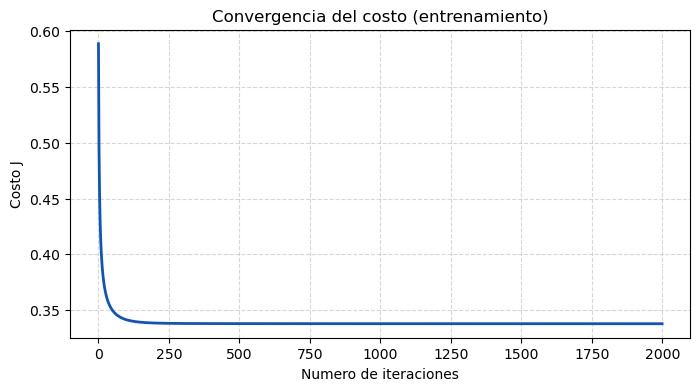

theta calculado por el descenso por el gradiente:
[-0.50975423 -0.02574208 -0.7914758  -0.11460824  1.4056824  -0.11903252
  0.08411101  0.46349309 -0.19155091 -0.17920821  0.03664384 -0.02723269
  0.86568519  0.11421203  0.04302062  0.41837774  0.34080168  0.18370435
  0.42931419  0.16841158  0.29004255  0.14132554 -0.3279306 ]

Costo final: 0.3378


In [11]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.3
num_iters = 2000

# inicializa theta (tamaño = numero de columnas de X_train_b, incluye el sesgo) y ejecuta el descenso por el gradiente
theta = np.zeros(X_train_b.shape[1])
theta, J_history = descensoGradiente(theta, X_train_b, y_train, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.figure(figsize=(8, 4))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2, color='#0d53c4')
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del costo (entrenamiento)')
pyplot.grid(True, linestyle='--', alpha=0.5)
pyplot.show()

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente:')
print(theta)
print(f'\nCosto final: {J_history[-1]:.4f}')

## 6. Validación del modelo

Con `theta` ya entrenado, se calcula la precisión tanto en el conjunto de entrenamiento como en el de prueba. El conjunto de prueba se normaliza usando la misma media y desviación estándar del entrenamiento (nunca se recalculan sobre el test), y no participó en ningún momento del ajuste de `theta`.

In [12]:
# Esta celda normaliza el conjunto de prueba con la misma media/desviación del entrenamiento.
# Sirve para que ambos conjuntos queden en la misma escala, sin que el modelo "vea" el test antes de tiempo.
X_test_norm = (X_test - mu) / sigma
X_test_b = np.concatenate([np.ones((X_test.shape[0], 1)), X_test_norm], axis=1)

def predict(theta, X):
    # Esta función convierte la probabilidad sigmoide en una clase (0 o 1) usando el umbral 0.5.
    # Sirve para pasar de una predicción continua a una etiqueta discreta.
    p = sigmoid(X.dot(theta))
    return (p >= 0.5).astype(int)

In [13]:
# Esta celda mide qué tan bien clasifica el modelo tanto en entrenamiento como en prueba.
# Sirve para detectar si el modelo generaliza bien o si está sobreajustado.
pred_train = predict(theta, X_train_b)
precision_train = np.mean(pred_train == y_train) * 100

pred_test = predict(theta, X_test_b)
precision_test = np.mean(pred_test == y_test) * 100

print(f'Precisión en entrenamiento: {precision_train:.2f}%')
print(f'Precisión en prueba: {precision_test:.2f}%')

Precisión en entrenamiento: 87.34%
Precisión en prueba: 45.11%


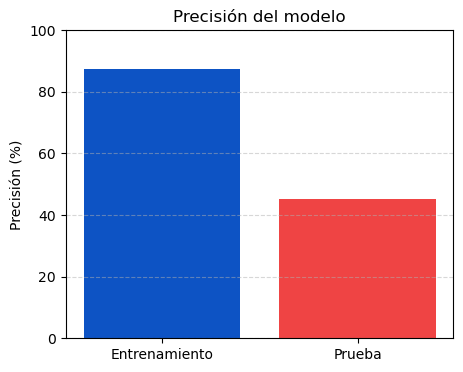

In [14]:
# Esta celda grafica la precisión en entrenamiento vs prueba.
# Sirve para visualizar de un vistazo la efectividad general del modelo.
pyplot.figure(figsize=(5, 4))
pyplot.bar(['Entrenamiento', 'Prueba'], [precision_train, precision_test], color=['#0d53c4', '#ef4444'])
pyplot.ylabel('Precisión (%)')
pyplot.ylim(0, 100)
pyplot.title('Precisión del modelo')
pyplot.grid(True, axis='y', linestyle='--', alpha=0.5)
pyplot.show()

In [15]:
# Esta celda muestra ejemplos puntuales de predicción vs valor real en el conjunto de prueba.
# Sirve para inspeccionar cualitativamente los aciertos y errores del modelo.
etiquetas = ['neutral or dissatisfied', 'satisfied']
for i in range(15):
    marca = '✓' if pred_test[i] == y_test[i] else '✗'
    print(f'Real: {etiquetas[int(y_test[i])]:25s} | Predicho: {etiquetas[pred_test[i]]:25s} {marca}')

Real: neutral or dissatisfied   | Predicho: satisfied                 ✗
Real: neutral or dissatisfied   | Predicho: neutral or dissatisfied   ✓
Real: satisfied                 | Predicho: neutral or dissatisfied   ✗
Real: neutral or dissatisfied   | Predicho: neutral or dissatisfied   ✓
Real: neutral or dissatisfied   | Predicho: neutral or dissatisfied   ✓
Real: neutral or dissatisfied   | Predicho: neutral or dissatisfied   ✓
Real: neutral or dissatisfied   | Predicho: satisfied                 ✗
Real: neutral or dissatisfied   | Predicho: neutral or dissatisfied   ✓
Real: neutral or dissatisfied   | Predicho: neutral or dissatisfied   ✓
Real: neutral or dissatisfied   | Predicho: neutral or dissatisfied   ✓
Real: neutral or dissatisfied   | Predicho: neutral or dissatisfied   ✓
Real: satisfied                 | Predicho: neutral or dissatisfied   ✗
Real: neutral or dissatisfied   | Predicho: satisfied                 ✗
Real: neutral or dissatisfied   | Predicho: neutral or dissatisf

## Conclusión

El modelo de regresión logística se entrenó por descenso por gradiente sobre el 100% de `train.csv` (normalizado y con término de sesgo), y se validó contra `test.csv`, un conjunto que no participó del entrenamiento. La gráfica de convergencia confirma que el costo disminuye de forma estable, y la comparación de precisión entre entrenamiento y prueba permite verificar si el modelo generaliza correctamente a pasajeros que nunca vio.